In [8]:
from diffusers import UNet2DModel, DDPMScheduler, VQModel
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
import lpips

from utils import im2tensor, viewimage
from operators import LinearOperator
from metrics import ImageMetrics

torch.manual_seed(6)

In [9]:
# run only once
download = False
if download:
    !wget -nc -O ffhq256-1k-validation.zip 'https://www.dropbox.com/scl/fi/pppstbdsf0em6o0qscruc/ffhq256-1k-validation.zip?rlkey=xl7nwv2nxb6yvsirr3wad77hm'
    !unzip -nq ffhq256-1k-validation.zip
    vqvae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae")
    unet = UNet2DModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="unet")
    scheduler = DDPMScheduler.from_pretrained("CompVis/ldm-celebahq-256", subfolder="scheduler")
    vqvae.save_pretrained("./models/vqvae")
    unet.save_pretrained("./models/unet")
    scheduler.save_pretrained("./models/scheduler")

else:
    vqvae = VQModel.from_pretrained("./models/vqvae", torch_dtype=torch.float32)
    unet = UNet2DModel.from_pretrained("./models/unet", torch_dtype=torch.float32)
    scheduler = DDPMScheduler.from_pretrained("./models/scheduler")

The config attributes {'timestep_values': None, 'timesteps': 1000} were passed to DDPMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

unet.to(device)
vqvae.to(device)

print(device)

cpu


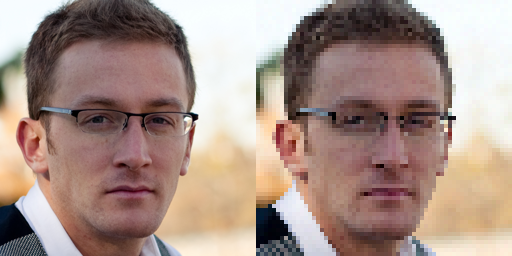

In [12]:
idx = 462
x0 = im2tensor(plt.imread('ffhq256-1k-validation/'+str(idx).zfill(5)+'.png'), device=device)
x_true = x0.clone()
imgshape = x0.shape
imgshape_latent = (1, unet.config.in_channels, unet.sample_size, unet.sample_size)

MODE = "super_resolution"
sigma_noise = 0.01

operator = LinearOperator(MODE, imgshape, device)

y = operator.measure(x_true, nu=sigma_noise)

vis_y = operator.visualize_y(y)

viewimage(torch.cat((x_true, vis_y), dim=3), titre='Ground truth and measurements', displayfilename=False)

In [70]:
alphas = scheduler.alphas.to(device)
betas = scheduler.betas.to(device)
alphas_bar = scheduler.alphas_cumprod.to(device)
betas_bar = 1.0 - alphas_bar

 10%|▉         | 99/1000 [00:24<03:42,  4.06it/s]

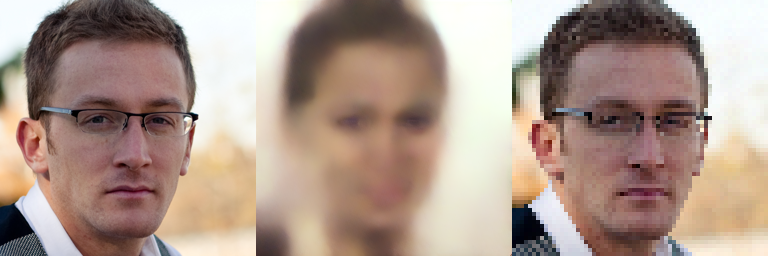

 20%|█▉        | 199/1000 [00:49<03:19,  4.02it/s]

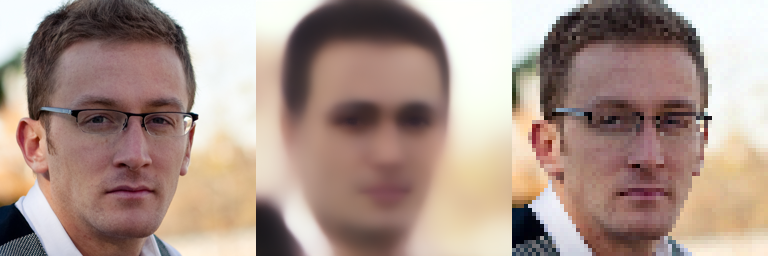

 30%|██▉       | 299/1000 [01:14<02:52,  4.07it/s]

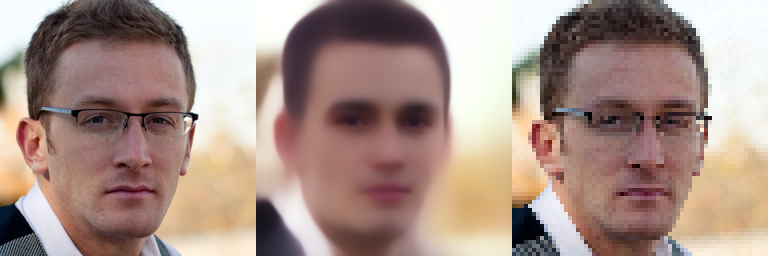

 40%|███▉      | 399/1000 [01:39<02:27,  4.07it/s]

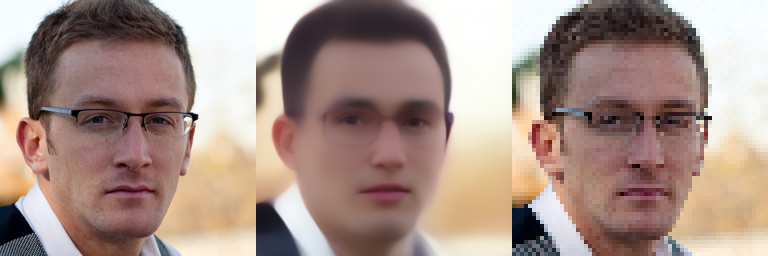

 50%|████▉     | 499/1000 [02:04<02:04,  4.04it/s]

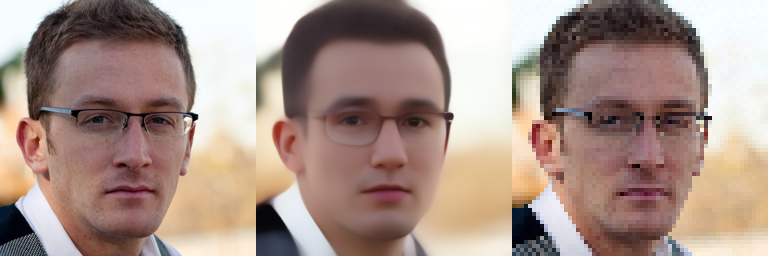

 60%|█████▉    | 599/1000 [02:29<01:39,  4.04it/s]

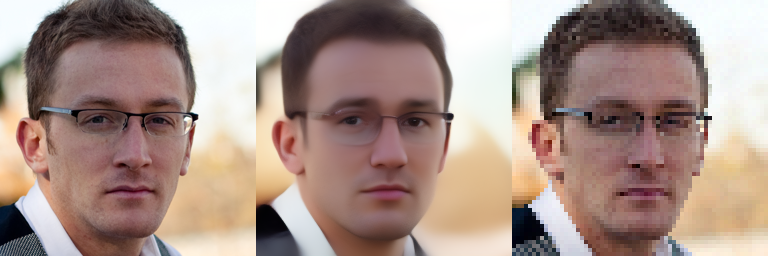

 70%|██████▉   | 699/1000 [02:54<01:14,  4.06it/s]

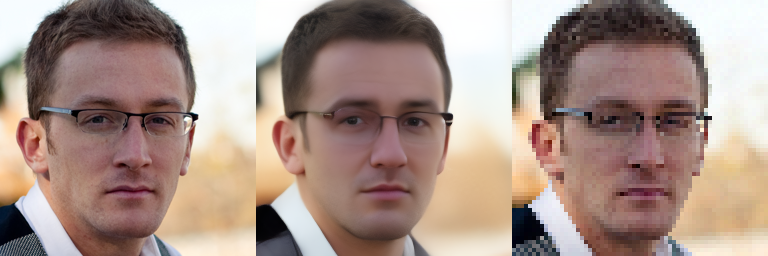

 80%|███████▉  | 799/1000 [03:19<00:49,  4.04it/s]

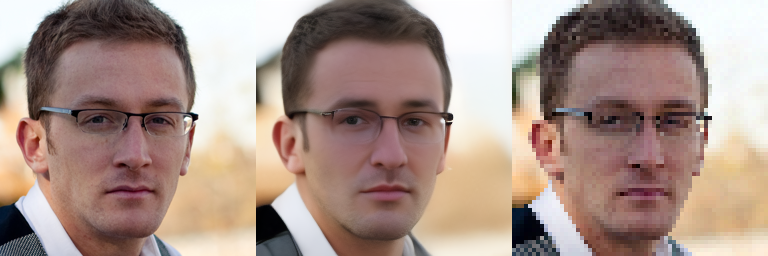

 90%|████████▉ | 899/1000 [03:44<00:24,  4.04it/s]

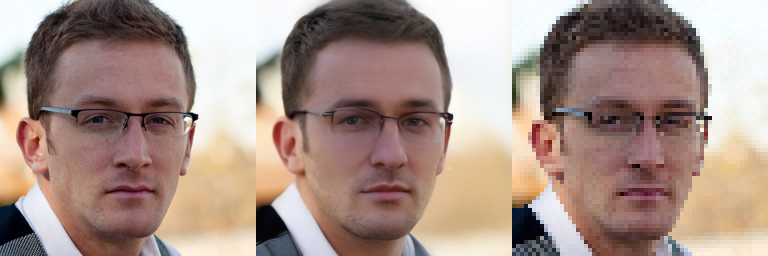

100%|█████████▉| 999/1000 [04:09<00:00,  3.99it/s]

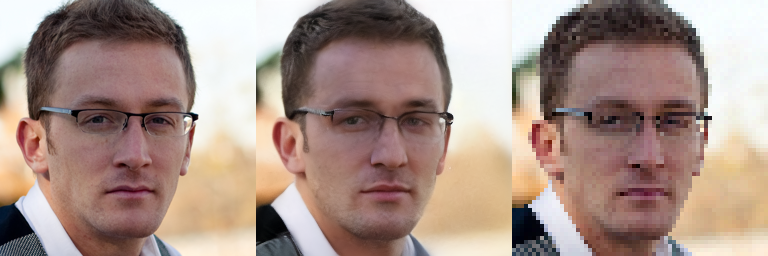

100%|██████████| 1000/1000 [04:09<00:00,  4.00it/s]


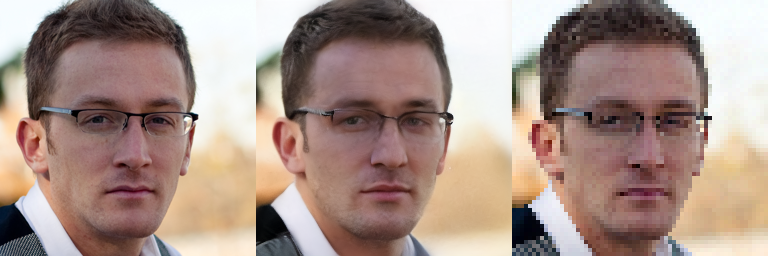

In [ ]:
z = torch.randn(imgshape_latent).to(device)

unet.eval()
vqvae.eval()

eta = 1.
gamma = 0.1
#zeta_scale = 1.9

for t in tqdm(scheduler.timesteps):
    t = torch.tensor([t], device=device)

    z = z.detach().requires_grad_(True)

    with torch.amp.autocast("cuda"):
        s_residus = unet(z, t)["sample"]
        z0_hat =  (z - torch.sqrt(betas_bar[t]) * s_residus) / torch.sqrt(alphas_bar[t])
        x0_hat = vqvae.decode(z0_hat)[0]

    resid = operator.forward(x0_hat) - y
    loss_likelihood = torch.linalg.norm(resid)
    
    ortho_project = x0_hat - operator.transpose(operator.forward(x0_hat))
    parallel_project = operator.transpose(y)
    gluing_image = (parallel_project + ortho_project).clamp(-1.0, 1.0)

    encoded_z_0 = vqvae.encode(gluing_image).latents
    loss_glue = torch.linalg.norm(encoded_z_0 - z0_hat)

    loss = eta * loss_likelihood + gamma * loss_glue

    grad = torch.autograd.grad(loss, z)[0]
    zeta = torch.sqrt(alphas_bar[t]) #zeta_scale/np.sqrt(loss.item())

    z_prim = (z - (betas[t] / torch.sqrt(betas_bar[t])) * s_residus) / torch.sqrt(alphas[t])

    eps = torch.sqrt(betas[t]) * torch.randn_like(z) if t.item() > 0 else 0
    z = z_prim + eps - zeta * grad

    if t.item() % 100 == 0:
        viewimage(torch.cat((x_true, x0_hat, vis_y), dim=3), titre=f"t={t.item()}", displayfilename=False)


with torch.no_grad():
    with torch.amp.autocast("cuda"):
        final_img = vqvae.decode(z.detach())[0]

viewimage(torch.cat((x_true, final_img, vis_y), dim=3), titre="Final_Results")

In [86]:
evaluator = ImageMetrics(device=device)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [88]:
results = evaluator.evaluate_all(x_true, final_img, data_range=2.0)

print(f"PSNR  : {results['PSNR']:.2f} dB")
print(f"SSIM  : {results['SSIM']:.4f}")
print(f"LPIPS : {results['LPIPS']:.4f}")

PSNR  : 26.78 dB
SSIM  : 0.7637
LPIPS : 0.1139
